In [1]:
%%capture --no-stderr
%pip install -U langchain_openai langgraph trustcall langchain_core

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain 1.2.15 requires langgraph<1.2.0,>=1.1.5, but you have langgraph 1.2.4 which is incompatible.

[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import os, getpass

def _set_env(var: str):
    # Check if the variable is set in the OS environment
    env_value = os.environ.get(var)
    if not env_value:
        # If not set, prompt the user for input
        env_value = getpass.getpass(f"{var}: ")
    
    # Set the environment variable for the current process
    os.environ[var] = env_value

_set_env("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_WORKSPACE_ID"] = ""

In [17]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph , START , END , MessagesState 
from langchain.messages import AIMessage , HumanMessage , SystemMessage
from trustcall import create_extractor
from dotenv import load_dotenv
from pydantic import Field , BaseModel
from typing import Literal
load_dotenv()


True

In [18]:
# Create LLM 
llm = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite",

)

In [34]:
class PersonalDetails(BaseModel):
    # Fixed: added description= explicitly so it's not treated as a default string value
    dob: str = Field(description="Date of birth of the user (DD-MM-YYYY) format")
    gender: Literal['male', 'female'] = Field(description="Gender of the user")
    phone: str = Field(description="Phone number")

class UserProfile(BaseModel):
    user_name: str = Field(description="User name of the user or name of the user")
    personal_details: PersonalDetails = Field(description="Personal details of the user")

In [39]:
trust_call_lmm = create_extractor(
                                  llm , 
                                  tools=[UserProfile] , 
                                  tool_choice='UserProfile')

In [40]:
# Conversation
conversation = [HumanMessage(content="Hi, I'm Lance."), 
                AIMessage(content="Nice to meet you, Lance."), 
                HumanMessage(content="I really like biking around San Francisco.My birthday is on 5th of april and I am a male ")]

In [41]:
system_message =  "Extract the user profile from the following conversation"



result  = trust_call_lmm.invoke({"messages" : [SystemMessage(system_message)] + conversation})

Key '$defs' is not supported in schema, ignoring


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [42]:
result['responses'][0].model_dump()

{'user_name': 'Lance',
 'personal_details': {'dob': '05-04-1990',
  'gender': 'male',
  'phone': 'not_provided'}}

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [5]:
builder = StateGraph(MessagesState)
builder.add_node('call_model' , call_model)
builder.add_edge(START , 'call_model')
builder.add_edge('call_model' , END)


In [6]:
agent = builder.compile()

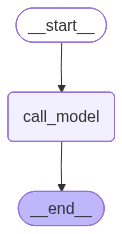

In [7]:
agent

In [8]:
agent.invoke({"messages" :"How r u GPT "})

Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


{'messages': [HumanMessage(content='How r u GPT ', additional_kwargs={}, response_metadata={}, id='6692be53-4a78-43d0-80e8-ed3ae464b24f'),
  AIMessage(content=[{'type': 'text', 'text': "I'm doing great, thank you for asking! How are you doing today? Is there anything I can help you with?", 'extras': {'signature': 'EjQKMgEMOdbHotJRcAs+N3R85PCfwajUN8x1g+wazsfxlQIeFX7AvLNFopNRIS8QGG1l3PIK'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019ea82f-7b04-7d23-b9b7-fe42a59ed2d0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 6, 'output_tokens': 26, 'total_tokens': 32, 'input_token_details': {'cache_read': 0}})]}

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
